In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
import wandb



In [4]:
BATCH_SIZE = 64
NUM_CLASSES = 7
LEARNING_RATE = 0.01
EPOCHS_NUM = 50
wandb.init(
    project="classification-model-comparison",
    config={
        "batch_size": BATCH_SIZE,
        "num_classes": NUM_CLASSES,
        "learning_rate": LEARNING_RATE,
        "epochs": LEARNING_RATE,
        "model":"resnet50",
    }
)
config = wandb.config

wandb: Currently logged in as: tetiana-trachuk-kn-2021 (tetiana-trachuk-kn-2021-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


In [5]:
device = torch.device('cpu')

augmentation_transforms = transforms.Compose([
    transforms.RandomRotation(degrees=15),
    transforms.RandomResizedCrop(size=64, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])  # Normalize
])

test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

dataset = ImageFolder(root='C:/Diploma/classification_dataset', transform=augmentation_transforms)

labels = [label for _, label in dataset]

train_indices, test_indices = train_test_split(
    range(len(dataset)), test_size=0.15, stratify=labels, random_state=42
)

# Створення підмножин датасету
train_dataset = Subset(dataset, train_indices)
test_dataset = Subset(dataset, test_indices)

# Оновлення трансформації для тестового набору
dataset.transform = augmentation_transforms  # Для навчальної вибірки
test_dataset.dataset.transform = test_transforms  # Для тестової вибірки

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=True)


print(f"Classes: {dataset.classes}")
print(f"Total samples: {len(dataset)}")
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

Classes: ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k']
Total samples: 14317
Training samples: 12169
Testing samples: 2148



Displaying first 10 samples from Training Dataset:


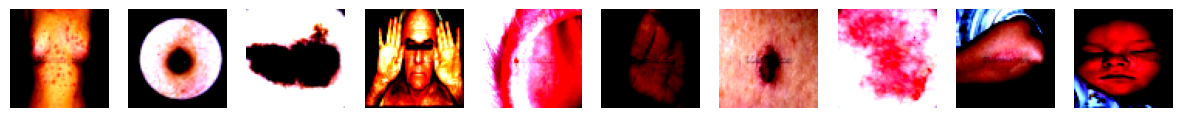

Class Labels Mapping: {5: '7. Psoriasis pictures Lichen Planus and related diseases - 2k', 4: '6. Benign Keratosis-like Lesions (BKL) 2624', 6: '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', 3: '4. Basal Cell Carcinoma (BCC) 3323', 2: '3. Atopic Dermatitis - 1.25k'}

Displaying first 10 samples from Testing Dataset:


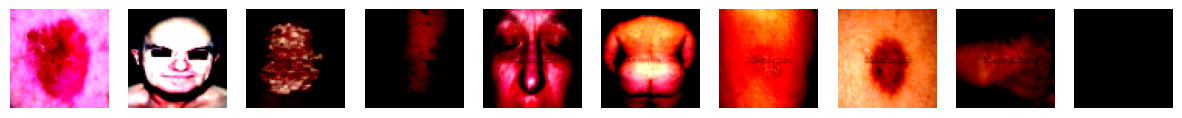

Class Labels Mapping: {5: '7. Psoriasis pictures Lichen Planus and related diseases - 2k', 4: '6. Benign Keratosis-like Lesions (BKL) 2624', 6: '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', 3: '4. Basal Cell Carcinoma (BCC) 3323', 2: '3. Atopic Dermatitis - 1.25k', 1: '10. Warts Molluscum and other Viral Infections - 2103'}


In [6]:
import matplotlib.pyplot as plt

print("\nDisplaying first 10 samples from Training Dataset:")
plt.figure(figsize=(15, 5))

class_labels = {}

for i in range(10):
    image, label = train_dataset[i]  
    class_labels[label] = train_dataset.dataset.classes[label]

    plt.subplot(1, 10, i + 1)
    plt.imshow(image.permute(1, 2, 0).clamp(0, 1).numpy())  # Нормалізація в діапазон [0,1]
    plt.axis('off')

plt.show()
print("Class Labels Mapping:", class_labels)

print("\nDisplaying first 10 samples from Testing Dataset:")
plt.figure(figsize=(15, 5))

for i in range(10):
    image, label = test_dataset[i]
    class_labels[label] = test_dataset.dataset.classes[label]

    plt.subplot(1, 10, i + 1)
    plt.imshow(image.permute(1, 2, 0).clamp(0, 1).numpy())  # Нормалізація в діапазон [0,1]
    plt.axis('off') 

plt.show()
print("Class Labels Mapping:", class_labels)


In [7]:
model = models.resnet50(pretrained=True)

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, config.num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


c:\Diploma\Diploma\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Diploma\Diploma\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [8]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=config.learning_rate, momentum=0.9)


In [9]:
from utils import evaluate, train


def train_model(model, criterion, optimizer, num_epochs):
    for epoch in range(num_epochs):
        train_loss, train_acc, train_prec, train_rec, train_f1 = train(model, criterion, optimizer,device,train_loader)
        eval_acc, eval_prec, eval_rec, eval_f1 = evaluate(model,device,test_loader)

        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Prec: {train_prec:.4f}, Rec: {train_rec:.4f},F1: {train_f1:.4f}")
        wandb.log({
                "Training/Loss": train_loss,
                "Training/Accuracy": train_acc,
                "Training/Precision": train_prec,
                "Training/Recall": train_rec,
                "Training/F1_Score": train_f1
            })

        print(f"Eval  - Acc: {eval_acc:.4f}, Prec: {eval_prec:.4f}, Rec: {eval_rec:.4f}, F1: {eval_f1:.4f}")
        wandb.log({
        "Evaluation/Accuracy": eval_acc,
        "Evaluation/Precision": eval_prec,
        "Evaluation/Recall": eval_rec,
        "Evaluation/F1_Score": eval_f1
    })

    return model

model = train_model(model, criterion, optimizer, EPOCHS_NUM)

Epoch [1/50]
Train - Loss: 1.2441, Acc: 0.5207, Prec: 0.5167, Rec: 0.5207,F1: 0.5166
Eval  - Acc: 0.5074, Prec: 0.5719, Rec: 0.5074, F1: 0.5070
Epoch [2/50]
Train - Loss: 0.9751, Acc: 0.6248, Prec: 0.6229, Rec: 0.6248,F1: 0.6221
Eval  - Acc: 0.6536, Prec: 0.6704, Rec: 0.6536, F1: 0.6473
Epoch [3/50]
Train - Loss: 0.7338, Acc: 0.7253, Prec: 0.7240, Rec: 0.7253,F1: 0.7241
Eval  - Acc: 0.6169, Prec: 0.6407, Rec: 0.6169, F1: 0.6165
Epoch [4/50]
Train - Loss: 0.7919, Acc: 0.7074, Prec: 0.7062, Rec: 0.7074,F1: 0.7062
Eval  - Acc: 0.6606, Prec: 0.6708, Rec: 0.6606, F1: 0.6587
Epoch [5/50]
Train - Loss: 0.6730, Acc: 0.7508, Prec: 0.7500, Rec: 0.7508,F1: 0.7501
Eval  - Acc: 0.6648, Prec: 0.6702, Rec: 0.6648, F1: 0.6626
Epoch [6/50]
Train - Loss: 0.6172, Acc: 0.7781, Prec: 0.7775, Rec: 0.7781,F1: 0.7776
Eval  - Acc: 0.6657, Prec: 0.6709, Rec: 0.6657, F1: 0.6635
Epoch [7/50]
Train - Loss: 0.4641, Acc: 0.8299, Prec: 0.8299, Rec: 0.8299,F1: 0.8298
Eval  - Acc: 0.6802, Prec: 0.6849, Rec: 0.6802, F1:

In [10]:
model.eval()
correct = 0
total = 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total
print(f'Final Accuracy on {len(test_dataset)} test images: {accuracy:.2f} %')

wandb.log({"final_test_accuracy": accuracy})



Final Accuracy on 2148 test images: 71.28 %


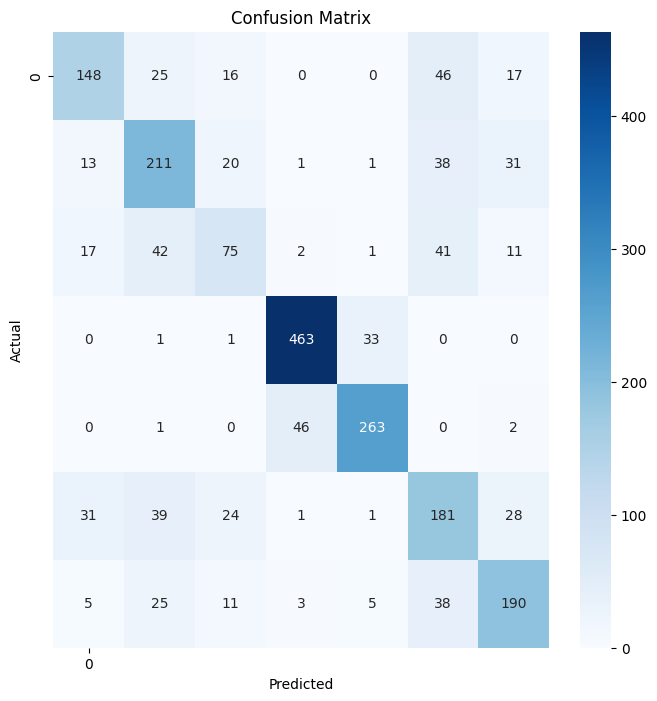

In [11]:
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix

model.eval()
correct, total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=NUM_CLASSES, yticklabels=NUM_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Логування у wandb (якщо потрібно)
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=NUM_CLASSES, yticklabels=NUM_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
wandb.log({"confusion_matrix": wandb.Image(fig)})
plt.close()

In [12]:
torch.save(model.state_dict(), "../files/classification_model_resnet.pth")
print("Model saved as 'classification_model_resnet.pth'")

wandb.finish()

Model saved as 'classification_model_resnet.pth'


Evaluation/Accuracy,▁▆▅▆▆▇▇▆▇▆▇██▇▇█▇▇▆█▇▇▇█▇▇█▇█████▇▇▇▇▇▇█
Evaluation/F1_Score,▃▁▄▄▄▇▅▆▅▇▇▆▆▆▇▇▄▇██▆█▆▇▇▇█▆████▇▇▇▅▆▆▇▇
Evaluation/Precision,▁▅▄▅▅▆▇▆▇▇▇██▇▇▇█▇▆██▇▇▇█▇▇█████▇▇▇▆▆▇▇▇
Evaluation/Recall,▁▆▅▆▆▇▇▆▇▇█▇▇▇█▇▆███▇█▇█▇▇█▇█████▇▇▇▇▇▇█
Training/Accuracy,▁▃▄▄▄▆▇▇▇▇▇███████████████████████▇▅████
Training/F1_Score,▁▃▄▄▄▆▇▇▇▇▇███████████████████████▇▅████
Training/Loss,█▆▅▅▅▄▂▂▃▂▂▁▁▁▁▁▁▁▁▁▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▄▁▁▁
Training/Precision,▁▃▄▄▄▆▇▇▇▇▇███████████████████████▇▅████
Training/Recall,▁▃▃▃▄▇▇▆▇▇██████████▇█▇███████████▇▅▇███
final_test_accuracy,▁
Evaluation/Accuracy,0.71276
